# 01. 최종 취약지수 DBSCAN 권역화

- 대상: 최종 취약지수가 계산된 취약노인 1명 이상 서울 100m 격자.
- 점수가 높을수록 취약하다. 상위 10·20·30%는 각각 전체 21,263개 격자의 분위수로 선정한다. 경계 동점은 모두 포함한다.
- DBSCAN: 격자 중심점, EPSG:5179 미터 좌표, `eps=150m`, `min_samples=4`. 대각선 인접까지 연결한다.
- 권역에 속하지 않은 격자는 고립 격자로 유지한다. 10·30% 결과는 비교에만 사용한다.
- 이 분석은 점수 상위 격자의 공간적 묶음이며 정책 개입 효과나 통계적 유의성을 검증하지 않는다.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.cluster import DBSCAN
from IPython.display import display

start = Path.cwd().resolve()
ROOT = next(p for p in [start, *start.parents] if (p / 'data/raw').is_dir() and (p / 'code').is_dir())
SCORE_PATH = ROOT / 'data/processed/final_score/서울시_100m_최종취약지수/서울시_100m_최종취약지수.csv'
GRID_PATH = ROOT / 'data/processed/spatial/서울시_격자_100m_행정동_기본테이블.gpkg'
OUT = ROOT / 'data/processed/vulnerability_region'
assert SCORE_PATH.is_file() and GRID_PATH.is_file()
pd.set_option('display.max_columns', 30)


## 1. 입력 데이터 점검

- 점수·인구·중심점 결측과 중복 격자를 확인한다.
- 공간 테이블의 CRS, 좌표 범위, `GRID_CD` 연결을 확인한다.


In [2]:
score = pd.read_csv(SCORE_PATH, encoding='utf-8-sig')
grid = gpd.read_file(GRID_PATH, columns=['GRID_CD', '중심점_x', '중심점_y', 'geometry'])
required = ['GRID_CD', '최종취약지수', '취약노인수', '중심점_x', '중심점_y', '경계대리적용']
assert set(required).issubset(score.columns)
assert not score[required].isna().any().any()
assert not score['GRID_CD'].duplicated().any() and not grid['GRID_CD'].duplicated().any()
assert score['취약노인수'].gt(0).all() and score['최종취약지수'].between(0, 1).all()
assert grid.crs.to_epsg() == 5179 and grid.geometry.notna().all()
assert score['GRID_CD'].isin(grid['GRID_CD']).all()
coord = score[['GRID_CD', '중심점_x', '중심점_y']].merge(
    grid[['GRID_CD', '중심점_x', '중심점_y']], on='GRID_CD', validate='one_to_one', suffixes=('_score', '_grid')
)
for axis in ['x', 'y']:
    assert np.allclose(coord[f'중심점_{axis}_score'], coord[f'중심점_{axis}_grid'])
print(f'점수 격자 {len(score):,}개 / 공간 격자 {len(grid):,}개 / 일치 {len(coord):,}개')
print(f'취약노인 합계 {score["취약노인수"].sum():,.0f}명 / 경계 대리 적용 {score["경계대리적용"].sum():,}개')
print(f'CRS {grid.crs} / 점수 격자 중심점 범위 X {score["중심점_x"].min():.0f}~{score["중심점_x"].max():.0f}, Y {score["중심점_y"].min():.0f}~{score["중심점_y"].max():.0f}')


점수 격자 21,263개 / 공간 격자 60,528개 / 일치 21,263개
취약노인 합계 168,748명 / 경계 대리 적용 292개
CRS EPSG:5179 / 점수 격자 중심점 범위 X 938150~971950, Y 1937350~1965850


## 2. 상위 10·20·30% 권역화

- 같은 거리·밀도 설정을 적용해 취약격자 수, 권역 수, 고립 격자, 최대 권역을 비교한다.
- 최대 권역 비중은 권역 포함 격자 중 가장 큰 권역의 비율이다.


In [3]:
cases = {}
summary = []
for pct in [10, 20, 30]:
    cutoff = score['최종취약지수'].quantile(1 - pct / 100)
    target = score.loc[score['최종취약지수'].ge(cutoff)].sort_values('GRID_CD').copy()
    target['DBSCAN_label'] = DBSCAN(eps=150, min_samples=4, algorithm='kd_tree').fit_predict(
        target[['중심점_x', '중심점_y']].to_numpy()
    )
    sizes = target.loc[target['DBSCAN_label'].ge(0), 'DBSCAN_label'].value_counts()
    included = int(sizes.sum())
    isolated = int(target['DBSCAN_label'].eq(-1).sum())
    assert len(target) == included + isolated
    cases[pct] = target
    summary.append({
        '상위 기준': f'{pct}%', '경계 점수': round(cutoff, 4), '대상 격자': len(target),
        '권역 수': len(sizes), '고립 격자': isolated, '고립 비율(%)': round(100 * isolated / len(target), 1),
        '권역 포함 격자': included, '최대 권역 격자': int(sizes.max()),
        '최대 권역 비중(%)': round(100 * sizes.max() / included, 1),
        '권역 크기 중앙값': float(sizes.median()), '100격자 이상 권역': int(sizes.ge(100).sum()),
        '취약노인 합계': int(target['취약노인수'].sum()),
    })
summary = pd.DataFrame(summary)
display(summary)


,상위 기준,경계 점수,대상 격자,권역 수,고립 격자,고립 비율(%),권역 포함 격자,최대 권역 격자,최대 권역 비중(%),권역 크기 중앙값,100격자 이상 권역,취약노인 합계
0,10%,0.6904,2127,138,614,28.9,1513,128,8.5,6.5,1,32401
1,20%,0.6246,4253,223,708,16.6,3545,297,8.4,9.0,4,59206
2,30%,0.5797,6379,275,782,12.3,5597,361,6.4,10.0,5,84686


## 3. 기준 확대에 따른 권역 변화

- 상위 기준을 넓힐 때 기존 권역이 합쳐지는 정도와 기존 고립 격자가 권역에 편입되는 정도를 확인한다.
- 기존 권역의 분할 여부는 동일한 DBSCAN 설정에서 입력 격자를 추가할 때의 정합성 점검이다.


In [4]:
changes = []
for before, after in [(10, 20), (20, 30)]:
    overlap = cases[before][['GRID_CD', 'DBSCAN_label']].merge(
        cases[after][['GRID_CD', 'DBSCAN_label']], on='GRID_CD', validate='one_to_one',
        suffixes=('_before', '_after')
    )
    previous = overlap.loc[overlap['DBSCAN_label_before'].ge(0)]
    assert previous.groupby('DBSCAN_label_before')['DBSCAN_label_after'].nunique().eq(1).all()
    merged = previous.groupby('DBSCAN_label_after')['DBSCAN_label_before'].nunique()
    merged_ids = merged.index[merged.gt(1)]
    noise = overlap.loc[overlap['DBSCAN_label_before'].eq(-1)]
    changes.append({
        '기준 변화': f'{before}% → {after}%', '기존 권역': previous['DBSCAN_label_before'].nunique(),
        '합쳐진 기존 권역': previous.loc[previous['DBSCAN_label_after'].isin(merged_ids), 'DBSCAN_label_before'].nunique(),
        '합쳐진 기존 권역 비율(%)': round(100 * previous.loc[previous['DBSCAN_label_after'].isin(merged_ids), 'DBSCAN_label_before'].nunique() / previous['DBSCAN_label_before'].nunique(), 1),
        '새 권역으로 편입된 기존 고립 격자': int(noise['DBSCAN_label_after'].ge(0).sum()),
        '기존 고립 격자': len(noise),
    })
changes = pd.DataFrame(changes)
display(changes)


,기준 변화,기존 권역,합쳐진 기존 권역,합쳐진 기존 권역 비율(%),새 권역으로 편입된 기존 고립 격자,기존 고립 격자
0,10% → 20%,138,62,44.9,391,614
1,20% → 30%,223,70,31.4,393,708


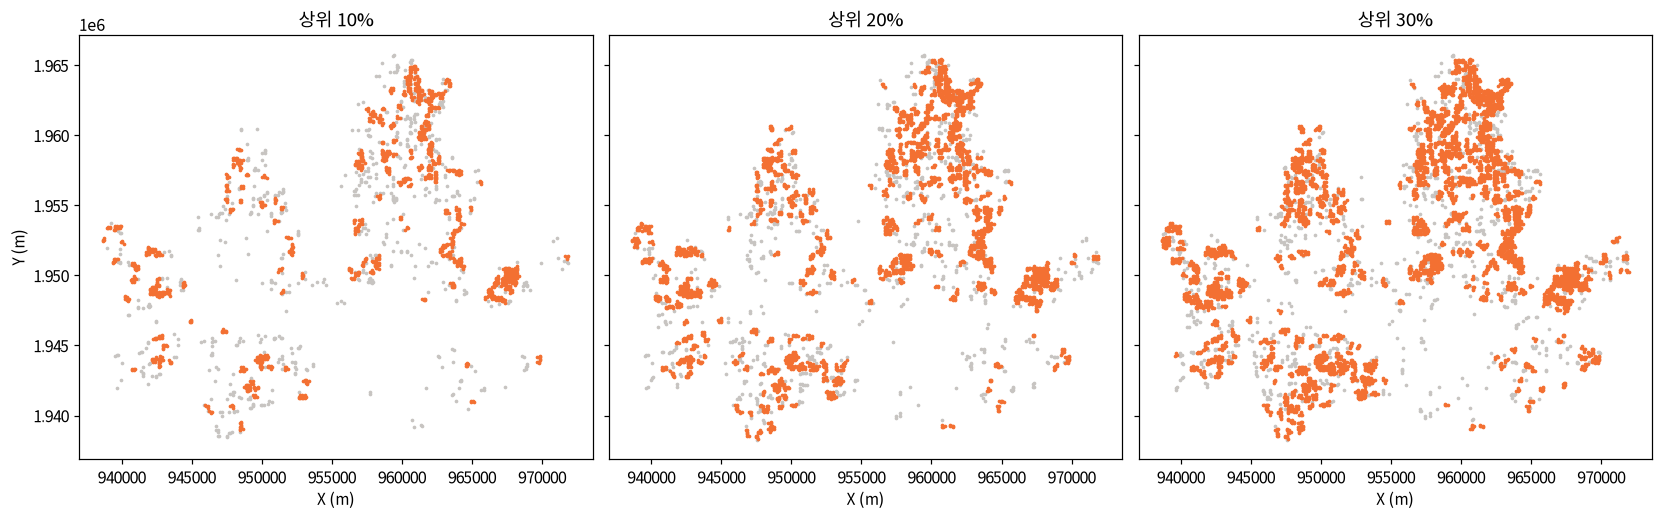

In [5]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ['Noto Sans KR', 'Noto Sans CJK KR', 'Malgun Gothic']:
    if font in fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams.update({'axes.unicode_minus': False, 'figure.dpi': 110})
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True, layout='constrained')
for ax, pct in zip(axes, [10, 20, 30]):
    part = cases[pct]
    core = part.loc[part['DBSCAN_label'].ge(0)]
    noise = part.loc[part['DBSCAN_label'].eq(-1)]
    ax.scatter(noise['중심점_x'], noise['중심점_y'], s=2, c='#c7c4c1', rasterized=True)
    ax.scatter(core['중심점_x'], core['중심점_y'], s=2, c='#f37032', rasterized=True)
    ax.set(title=f'상위 {pct}%', aspect='equal', xlabel='X (m)')
axes[0].set_ylabel('Y (m)')
plt.show()


## 4. 기준 선정 및 권역 결과

- 상위 20% 선정: 10%의 고립 비율이 높고, 30%는 권역 수와 표시 범위가 커진다. 20%는 고립 비율·권역 규모·기존 권역 병합 비율을 함께 고려한 절충안이다.
- 권역 ID는 최소 `GRID_CD` 순으로 부여한다. ID 번호는 취약 우선순위가 아니다.
- `min_samples=4`는 최종 권역의 최소 격자 수가 아니다. 경계 격자 배정에 따라 3격자 권역도 발생할 수 있다.
- `min_samples=4`는 최종 권역의 최소 격자 수가 아니다. 경계 격자 배정에 따라 3격자 권역도 발생할 수 있다.
- 선택 기준의 고립 격자는 연결표에 남기되 권역 도형에는 포함하지 않는다.


In [6]:
SELECTED_PCT = 20
selected = cases[SELECTED_PCT].copy()
group_order = (selected.loc[selected['DBSCAN_label'].ge(0)]
               .groupby('DBSCAN_label')['GRID_CD'].min().sort_values().index)
id_map = {label: f'VUL_{i:03d}' for i, label in enumerate(group_order, start=1)}
selected['취약권역_ID'] = selected['DBSCAN_label'].map(id_map)
selected['고립취약격자여부'] = selected['DBSCAN_label'].eq(-1)
assert selected['취약권역_ID'].notna().eq(~selected['고립취약격자여부']).all()
selected_grid = grid[['GRID_CD', 'geometry']].merge(
    selected[['GRID_CD', '시군구', '행정동', '최종취약지수', '취약노인수', '취약권역_ID']],
    on='GRID_CD', validate='one_to_one'
)
included_grid = selected_grid.dropna(subset=['취약권역_ID']).copy()
region_geom = included_grid[['취약권역_ID', 'geometry']].dissolve(by='취약권역_ID', as_index=False)
region_stats = included_grid.groupby('취약권역_ID', as_index=False).agg(
    평균최종취약지수=('최종취약지수', 'mean'), 최고최종취약지수=('최종취약지수', 'max'),
    취약노인수=('취약노인수', 'sum'), 취약격자수=('GRID_CD', 'size')
)
region = region_geom.merge(region_stats, on='취약권역_ID', validate='one_to_one')
region['권역면적_m2'] = region.geometry.area
assert len(region) == len(group_order) and region.geometry.is_valid.all()
assert region['취약격자수'].sum() == len(included_grid)
display(region.drop(columns='geometry').sort_values('평균최종취약지수', ascending=False).head(10).round(4))


,취약권역_ID,평균최종취약지수,최고최종취약지수,취약노인수,취약격자수,권역면적_m2
202,VUL_203,0.8200,0.8792,140,4,40000.0
40,VUL_041,0.7973,0.8598,53,4,40000.0
33,VUL_034,0.7864,0.8598,29,3,30000.0
204,VUL_205,0.7767,0.8914,838,10,100000.0
45,VUL_046,0.7734,0.8973,167,10,100000.0
28,VUL_029,0.7725,0.8568,49,4,40000.0
47,VUL_048,0.7681,0.8915,74,6,60000.0
158,VUL_159,0.7678,0.8794,63,4,40000.0
17,VUL_018,0.7654,0.8964,185,15,150000.0
97,VUL_098,0.7622,0.8381,82,6,60000.0


## 5. 결과 저장 및 재검증

- 선택한 20%의 격자-권역 연결표와 권역 도형만 저장한다.
- 저장한 파일을 다시 읽어 격자 수·권역 수·취약노인 총량·CRS를 검증한다.


In [7]:
OUT.mkdir(parents=True, exist_ok=True)
grid_out = OUT / '최종취약지수_DBSCAN_상위20_격자.csv'
region_out = OUT / '최종취약지수_DBSCAN_상위20_권역.gpkg'
selected[['GRID_CD', 'DBSCAN_label', '취약권역_ID', '고립취약격자여부']].to_csv(
    grid_out, index=False, encoding='utf-8-sig'
)
region.to_file(region_out, driver='GPKG', index=False)
saved_grid = pd.read_csv(grid_out, encoding='utf-8-sig')
saved_region = gpd.read_file(region_out)
assert len(saved_grid) == len(selected) and saved_grid['GRID_CD'].is_unique
assert len(saved_region) == len(group_order) and saved_region['취약권역_ID'].is_unique
assert saved_region.crs.to_epsg() == 5179 and saved_region.geometry.is_valid.all()
assert saved_grid['고립취약격자여부'].sum() == selected['고립취약격자여부'].sum()
assert saved_region['취약격자수'].sum() == saved_grid['취약권역_ID'].notna().sum()
assert np.isclose(saved_region['취약노인수'].sum(), included_grid['취약노인수'].sum())
print(f'선택: 상위 {SELECTED_PCT}% / 권역 {len(saved_region):,}개 / 포함 격자 {saved_region["취약격자수"].sum():,}개 / 고립 격자 {saved_grid["고립취약격자여부"].sum():,}개')
print(f'저장 및 재검증 완료: {grid_out.name}, {region_out.name}')


선택: 상위 20% / 권역 223개 / 포함 격자 3,545개 / 고립 격자 708개
저장 및 재검증 완료: 최종취약지수_DBSCAN_상위20_격자.csv, 최종취약지수_DBSCAN_상위20_권역.gpkg


## 6. 서울·구 경계와 취약권역

- 선택한 20% 권역을 서울 자치구 경계 위에 표시한다.
- 발표용 이미지 요청에 따라 PNG 한 장만 저장한다.


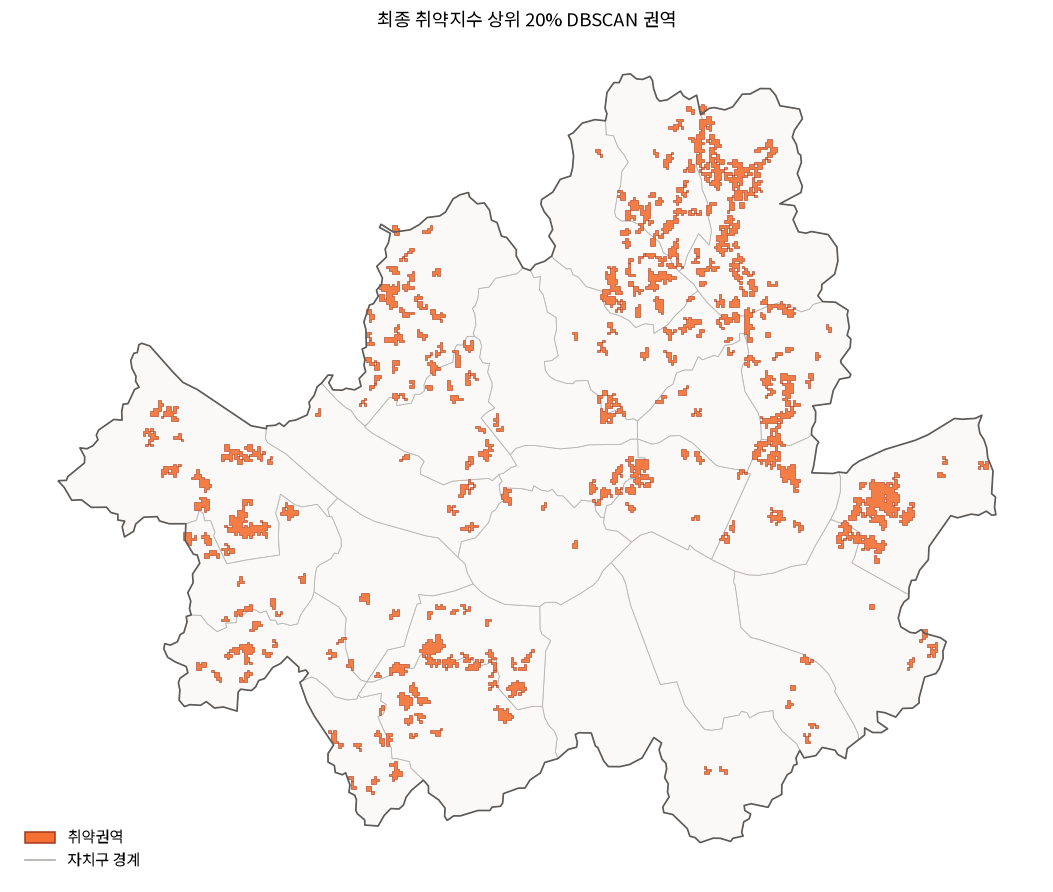

이미지 저장: C:\project\oracle_mnc_project\output\image\최종취약지수_DBSCAN_상위20_서울권역.png


In [8]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

gu_path = ROOT / 'data/raw/spatial/boundary/seoul_gu_boundary.json'
assert gu_path.is_file()
gu = gpd.read_file(gu_path).to_crs(saved_region.crs)
assert len(gu) == 25 and gu.geometry.is_valid.all()

fig, ax = plt.subplots(figsize=(11, 8), layout='constrained')
gu.plot(ax=ax, facecolor='#faf9f7', edgecolor='#b8b5b2', linewidth=0.55)
saved_region.plot(ax=ax, facecolor='#f37032', edgecolor='#a6381c', linewidth=0.4, alpha=0.9)
gpd.GeoSeries([gu.geometry.union_all()], crs=gu.crs).boundary.plot(
    ax=ax, color='#5d5b59', linewidth=1.1
)
ax.set(title='최종 취약지수 상위 20% DBSCAN 권역', aspect='equal')
ax.set_axis_off()
ax.legend(handles=[
    Patch(facecolor='#f37032', edgecolor='#a6381c', label='취약권역'),
    Line2D([0], [0], color='#b8b5b2', linewidth=1.2, label='자치구 경계'),
], loc='lower left', frameon=False)
image_path = ROOT / 'output/image/최종취약지수_DBSCAN_상위20_서울권역.png'
image_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(image_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'이미지 저장: {image_path}')
